# 我使用了什么库？

In [71]:
# 需要导入的库
import numpy as np
from seaborn import matrix
from sklearn.linear_model import LinearRegression

import torch
import torch.optim as optim
import torch.nn as nn
from torchviz import make_dot



# 然后，我要干什么？

目的是想了解pytorch在梯度计算方面是如何工作的
- 在此基础上仍然使用单特征线性回归模型
- 然后简单回顾numpy实现下线性回归的步骤

> 注意,我们现在没有去操心回归问题的结果,当前注意力放在**梯度下降**这一过程上

# 简单的回归问题

**Q**: 单特征线性回归模型的公式和每个参数的意义

**Q**: 如果把单特征线性回归视为神经网络，其计算图是什么样的？

# Numpy实现下线性回归的步骤

> 具体代码参考ch00

在处理梯度下降之前
1. 数据生成
2. 数据拆分

处理梯度下降
1. 随机初始化
2. 前向传播(预测)
3. 计算损失: 误差,损失,MSE,梯度下降的种类,损失面
4. 计算梯度: 横截面,偏导数,梯度,反向传递
5. 更新参数: 超参数,学习率，学习率的大小,标准化的必要性
6. 循环往复: 周期,梯度下降的各种更新次数,梯度下降的各种逼近方式


# 然后，我要干什么？

接下来要汇总ch00的代码,来实现numpy版本的线性回归模型，以此：
- 展示任务的大框架，因为步骤是基本不变的
- 展示主要的痛点和短板，来对比pytorch的便捷性

然后就会介绍pytorch的相关概念

# Numpy的线性回归实现

In [72]:
# 程序2-1: 生成数据
# seed: 42

N=100
true_b=1
true_w=2

np.random.seed(42)
x = np.random.rand(N,1)
ep = .1*np.random.randn(N,1)
y=true_b+true_w*x +ep

# 程序2-1: 切分数据

# 打乱数据集索引
idx = np.arange(N)
np.random.shuffle(idx)

# 使用前 80% 作为训练集
train_idx = idx[:int(N*.8)]
# 使用剩余索引作为验证集
val_idx = idx[int(N*.8):]

# 生成训练集和验证集
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

In [73]:
# 程序2-2: Numpy的线性回归实现

# 使用批量梯度下降
# 使用固定种子
np.random.seed(42)

# 随机初始化
b = np.random.randn(1)
w = np.random.randn(1)

print(b,w)


# 设置超参数
lr = 0.1
n_epochs = 1000

# 周期循环
for epoch in range(n_epochs):
    # 前向传递
    yhat = b + w * x_train
    # 计算误差和损失
    error = (yhat - y_train)
    # MSE
    loss = (error ** 2).mean()
    # 计算梯度
    b_grad = 2 * error.mean()
    w_grad = 2 * (x_train * error).mean()
    # 更新参数
    b = b - lr * b_grad
    w = w - lr * w_grad

print(b,w)




# 对比检测
linr = LinearRegression()
linr.fit(x_train, y_train)
print("Answer:",linr.intercept_,linr.coef_[0])







[0.49671415] [-0.1382643]
[1.02354094] [1.96896411]
Answer: [1.02354075] [1.96896447]


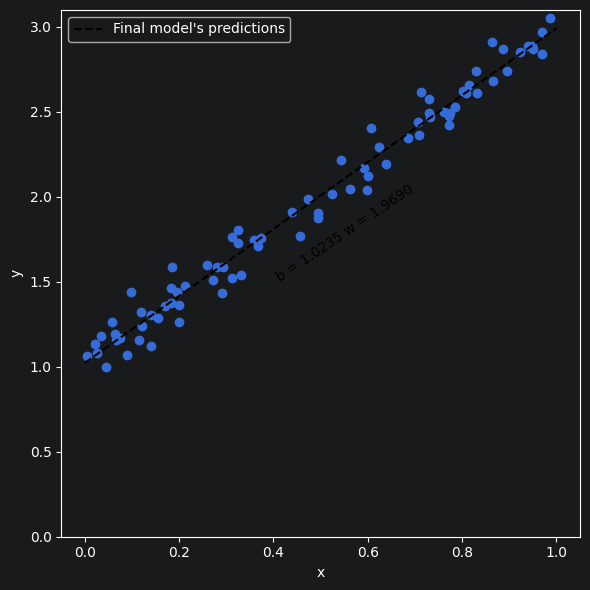

In [74]:
# 可视化对比结果
from plots.chapter1 import *
fig = figure3(x_train, y_train)

# Pytorch


## 张量

**Q:** 标量,向量,矩阵,张量的区别和实际划分是什么

**Q:** 张量在numpy中以什么方式出现

结合代码回答:

**Q:** pytorch如何创建一个张量和获取其形状

**Q:** pytorch reshape一个张量的方法,有什么特殊行为

**Q:** pytorch 如何复制一个张量,有什么注意事项和特殊行为


In [75]:
# 程序2-3: 创建pytoch 张量

var_scalar = torch.tensor(3.14159)
var_vector = torch.tensor([1,2,3])
var_matrix = torch.ones((2,3),dtype=torch.float)
var_matrix2 = torch.zeros((2,2),dtype=torch.int)
var_tensor = torch.randn([2,3,4],dtype=torch.float)

print(var_scalar,'\n',var_vector,'\n',var_matrix,'\n',var_matrix2,'\n',var_tensor)

# 访问张量
print(var_tensor[0,0,1],var_tensor[1][0][1])
print(var_tensor[0,0,(0,1,2)])
print(var_tensor[0,0,slice(0,3,2)])


tensor(3.1416) 
 tensor([1, 2, 3]) 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 
 tensor([[0, 0],
        [0, 0]], dtype=torch.int32) 
 tensor([[[-9.4680e-01,  1.9365e+00, -6.5485e-01,  1.2092e-01],
         [ 1.9268e+00, -9.8598e-04,  8.7542e-01, -3.2938e-01],
         [ 4.9228e-01,  1.9494e+00,  2.7158e-01, -1.2016e-01]],

        [[-3.5279e-01,  1.4033e+00,  8.9829e-02, -6.1571e-01],
         [-9.1762e-02, -9.4663e-01, -3.7004e-01,  5.6410e-01],
         [-4.0835e-01,  5.2908e-01,  4.2632e-02, -5.6587e-01]]])
tensor(1.9365) tensor(1.4033)
tensor([-0.9468,  1.9365, -0.6549])
tensor([-0.9468, -0.6549])


In [76]:
# 程序2-4: 获取张量形状

print(var_tensor.size(),var_tensor.shape)

# 标量是空形状,因为其零维度
print(var_scalar.size(),var_scalar.shape)

torch.Size([2, 3, 4]) torch.Size([2, 3, 4])
torch.Size([]) torch.Size([])


In [77]:
# 程序2-5: 重塑reshape张量

same_matrix = var_matrix2.view(1,4)
print(same_matrix,same_matrix.shape)

same_matrix[0,1] =1
print(var_matrix2,same_matrix)

# 注意reshape只是可能创建副本
same_matrix2 = var_matrix2.reshape(1,4)
same_matrix2[0,1] =2
print(var_matrix2,same_matrix2)

tensor([[0, 0, 0, 0]], dtype=torch.int32) torch.Size([1, 4])
tensor([[0, 1],
        [0, 0]], dtype=torch.int32) tensor([[0, 1, 0, 0]], dtype=torch.int32)
tensor([[0, 2],
        [0, 0]], dtype=torch.int32) tensor([[0, 2, 0, 0]], dtype=torch.int32)


In [78]:
# 程序2-6: 复制张量数据

# new_tensor方法: 注意warning内容,会继承dtype和grad相关信息
diff_matrix = var_matrix2.new_tensor(var_matrix2.view(1,4))
print(diff_matrix,diff_matrix.shape)

diff_matrix[0,1]=3
print(var_matrix2,diff_matrix)



tensor([[0, 2, 0, 0]], dtype=torch.int32) torch.Size([1, 4])
tensor([[0, 2],
        [0, 0]], dtype=torch.int32) tensor([[0, 3, 0, 0]], dtype=torch.int32)


C:\Users\a7183\AppData\Local\Temp\ipykernel_1524\1392254750.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  diff_matrix = var_matrix2.new_tensor(var_matrix2.view(1,4))


In [79]:
# 程序2-6: 复制张量数据

# clone + detach方法: 从计算图中删除张量
another_matrix = var_matrix2.view(1,4).clone().detach()
another_matrix[0,1]=4
print(var_matrix2,another_matrix,another_matrix.requires_grad)

tensor([[0, 2],
        [0, 0]], dtype=torch.int32) tensor([[0, 4, 0, 0]], dtype=torch.int32) False


## 然后，我要干什么？

固然创建了张量,但是pytorch是可以利用显卡(cuda)来及性能向量计算的

所以，以加载训练数据为例子，展示
- 如何将numpy传入pytorch
- 如何创建CPU和GPU张量

## 加载数据,设备和CUDA

**Q**: CPU张量和GPU张量是什么？有什么区别？

结合代码回答:

**Q**: 如何将numpy传入pytorch和转回,有什么特殊行为

**Q**: 如何检测是否存在设备并打印设备信息？

**Q**: 如何创建GPU张量？

**Q**: 如何识别张量类型？

**Q**: 如何将GPU张量变为numpy数组？

In [83]:
# 程序2-7: numpy数组装入pytorch数组

print(x_train.shape,y_train.shape)

# 效果等同from_numpy()
x_train_tensor = torch.as_tensor(x_train)

print(x_train.dtype,x_train_tensor.dtype)

float_tensor = x_train_tensor.float()
print(float_tensor.dtype)

# 转回numpy
print(float_tensor.numpy().dtype)

(80, 1) (80, 1)
float64 torch.float64
torch.float32
float32


In [87]:
# 程序2-7-1: as_tensor和from_numpy 教程

# 浅拷贝

dummpy_array = np.array([1,2,3])
dummpy_tensor = torch.as_tensor(dummpy_array)

dummpy_array[1]=0

print(dummpy_tensor)


# 复制数据

dummpy_array2 = torch.tensor(dummpy_array)
dummpy_array[1]=1
print(dummpy_array2,dummpy_tensor)


tensor([1, 0, 3], dtype=torch.int32)
tensor([1, 0, 3], dtype=torch.int32) tensor([1, 1, 3], dtype=torch.int32)


In [88]:
# 程序2-8: GPU环境配置和GPU张量创建

device = 'cuda' if torch.cuda.is_available() else 'cpu'

n_cudas = torch.cuda.device_count()
for i in range(n_cudas):
    print(torch.cuda.get_device_name(i),torch.cuda.get_device_capability(i))
,
# 张量创建
gpu_tensor = torch.as_tensor(x_train).to(device)
print(gpu_tensor[0])

NVIDIA GeForce MX150 (6, 1)


In [92]:
# 程序2-9: 加载Numpy到GPU张量

x_train_tensor = torch.as_tensor(x_train).float().to(device)
y_train_tensor = torch.as_tensor(y_train).float().to(device)

# type代表张量存在的位置
print(type(x_train),type(x_train_tensor),x_train_tensor.type())


<class 'numpy.ndarray'> <class 'torch.Tensor'> torch.cuda.FloatTensor


In [93]:
# 程序2-10: 从GPU张量到numpy

back_to_numpy = x_train_tensor.cpu().numpy()

print(back_to_numpy.shape)

(80, 1)


## 然后，我要干什么？

目前，pytorch张量的范围仅仅涉及了训练数据, 接着要把需要计算梯度的参数也加纳入pytorch的控制

##